In [1]:
import gdown
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
import os
import shutil

from MO810_API import MO810Dataset, MO810DataModule

In [4]:
class UTHARDataset(MO810Dataset):
    def __init__(self, data_dir, download=True, transform=None, split='train', to_tensor=True, shuffle=False):
        super().__init__()
        
        self.data_dir = data_dir
        self.dataset_dir = data_dir + "/UT-HAR"
        self.split = split
        self.transform = transform
        
        if download:
            self.download_data()

        if split == 'train':
            data_path = self.dataset_dir + "/data/X_train.csv"
            label_path = self.dataset_dir + "/label/y_train.csv"
            print(f"Loading from {data_path} / {label_path}")
        elif split == 'val':
            data_path = self.dataset_dir + "/data/X_val.csv"
            label_path = self.dataset_dir + "/label/y_val.csv"
            print(f"Loading from {data_path} / {label_path}")
        elif split == 'test':
            data_path = self.dataset_dir + "/data/X_test.csv"
            label_path = self.dataset_dir + "/label/y_test.csv"
            print(f"Loading from {data_path} / {label_path}")
        else:
            raise ValueError(f"Split name '{split}' is not valid. Select one of ['train', 'val', 'test'];")
            
        with open(data_path, 'rb') as f:
            self.samples = np.load(f).transpose((0,2,1))
            #print(self.samples.max(), self.samples.min())
        with open(label_path, 'rb') as f:
            self.labels = np.load(f)
        assert self.samples.shape[0] == self.labels.shape[0]

        if shuffle:
            rng = np.random.default_rng(seed=1)
            idxs = np.arange(self.samples.shape[0])
            rng.shuffle(idxs)
            self.samples = self.samples[idxs]
            self.labels = self.labels[idxs]

        if to_tensor:
            self.samples = torch.Tensor(self.samples)
            self.labels = torch.Tensor(self.labels).long()
    
    def download_data(self):
        if not os.path.exists(self.dataset_dir + "/data"):
            os.makedirs(self.dataset_dir, exist_ok=True)
            
            if not os.path.exists(self.dataset_dir + "/raw.zip"):
                drive_id = "1fEiI3nAoOsddR5qcJQXqz4ocM3aMAcwz"
                out = gdown.download(id=drive_id, output=self.dataset_dir + "/raw.zip")
            
            gdown.extractall(self.dataset_dir + "/raw.zip")
            os.rename(self.dataset_dir + "/UT_HAR/data", self.dataset_dir + "/data")
            os.rename(self.dataset_dir + "/UT_HAR/label", self.dataset_dir + "/label")

            shutil.rmtree(self.dataset_dir + "/UT_HAR")
            os.remove(self.dataset_dir + "/raw.zip")

    def __len__(self):
        return self.samples.shape[0]

    def __getitem__(self, index):
        sample = self.samples[index]
        if self.transform:
            sample = self.transform(sample)
            
        return sample, self.labels[index]

    def __str__(self):
        return f"UT-HAR Dataset. Split {self.split}. {len(self)} samples."
           
           
dataset = UTHARDataset("./data", shuffle=True)
print(dataset)
dataset[0][0].shape

Downloading...
From (original): https://drive.google.com/uc?id=1fEiI3nAoOsddR5qcJQXqz4ocM3aMAcwz
From (redirected): https://drive.google.com/uc?id=1fEiI3nAoOsddR5qcJQXqz4ocM3aMAcwz&confirm=t&uuid=00cfedc4-d167-44f0-9ff1-097a39c518fe
To: /home/bruno/master/aulas/MO810/Projeto-MO810-2025/src/bruno/data/UT-HAR/raw.zip
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 383M/383M [00:16<00:00, 22.6MB/s]


Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv
UT-HAR Dataset. Split train. 3977 samples.


torch.Size([90, 250])

In [5]:
class MinMaxScaler:
    def __init__(self, min_value, max_value):
        self.min_value = min_value
        self.max_value = max_value

        assert self.max_value != self.min_value, "Max and min value cannot be the equal"

    def __call__(self, data):
        assert isinstance(data, torch.Tensor), f"Expected data of type torch.Tensor, but got {type(data)}"
        return (data - self.min_value) / (self.max_value - self.min_value)

In [24]:
class UTHARDatamodule(MO810DataModule):
    def __init__(self, data_dir="./data", train_transform=None, val_transform=None, test_transform=None, batch_size=32, num_workers=4):
        super().__init__()
        self.data_dir = data_dir
        self.num_workers = num_workers
        self.batch_size = batch_size

        self.default_transform = MinMaxScaler(-10.666, 30.519) # Extracted from train data
        self.train_transform = train_transform
        self.val_transform = val_transform
        self.test_transform = test_transform

        self.label_names = ['Lie Down', 'Fall', 'Walk', 'Pick Up', 'Run', 'Sit Down', 'Stand Up'] # Guessing that this is the correct order

    def sample_dataset(self, dataset, fraction=None, samples_per_class=None):
        """
        Returns a sampled subset of the dataset based on a fraction of the total dataset
        or a fixed number of samples per class.
        Args:
            dataset (Dataset): The dataset to sample from.
            fraction (float, optional): Fraction of the dataset to use (0 < fraction ≤ 1).
            samples_per_class (int, optional): Number of samples per class to include.

        Returns:
            Subset: A subset of the dataset with the selected samples.

        Raises:
            ValueError: If both `fraction` and `samples_per_class` are provided.
        """
        if fraction != None and samples_per_class != None:
            raise ValueError("UTHAR ERROR: Cannot sample dataset using both fraction and samples_per_class")
        elif fraction:
            N = int(len(dataset) * fraction)
            return Subset(dataset, range(N))
        elif samples_per_class:
            count = [0] * 7
            indices = []
            for i, (_, label) in enumerate(dataset):
                if count[label] < samples_per_class: 
                    count[label] += 1
                    indices.append(i)
            return Subset(dataset, indices)
        else:
            return dataset
            
    def train_dataloader(self, fraction=None, samples_per_class=None):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.train_transform if self.train_transform else self.default_transform,
                               split='train',
                               to_tensor=True,
                               shuffle=True)
        dataset = self.sample_dataset(dataset, fraction=fraction, samples_per_class=samples_per_class)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, shuffle=True, num_workers=self.num_workers)

    def val_dataloader(self):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.val_transform if self.val_transform else self.default_transform,
                               split='val',
                               to_tensor=True,
                               shuffle=False)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, num_workers=self.num_workers)

    def test_dataloader(self):
        dataset = UTHARDataset(self.data_dir,
                               download=True,
                               transform=self.test_transform if self.test_transform else self.default_transform,
                               split='test',
                               to_tensor=True,
                               shuffle=False)
        return DataLoader(dataset=dataset, batch_size=self.batch_size, num_workers=self.num_workers)
        

Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


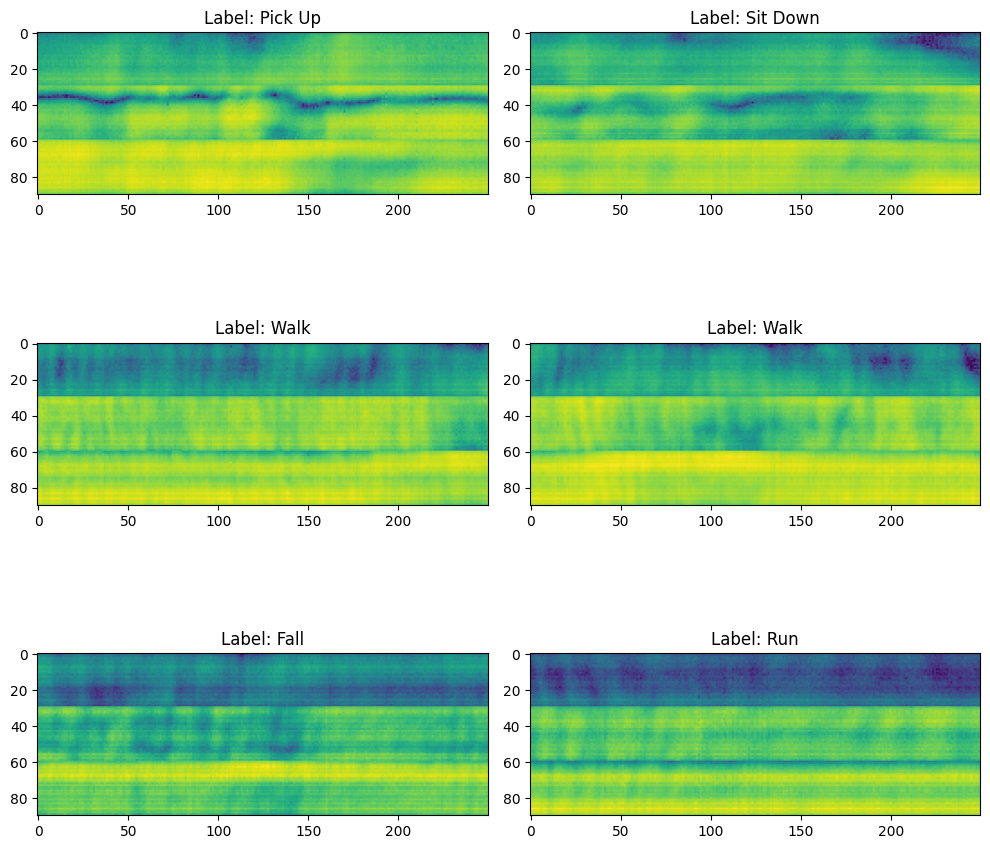

In [25]:
import matplotlib.pyplot as plt

datamodule = UTHARDatamodule()
train_loader = datamodule.train_dataloader()
probe_batch = next(iter(train_loader))

fig, axs = plt.subplots(3,2)
fig.set_size_inches(10,10)
for i in range(6):
    axs[i//2, i%2].imshow(probe_batch[0][i])
    label = probe_batch[1][i].item()
    axs[i//2, i%2].set_title(f"Label: {datamodule.label_names[label]}")

fig.set_tight_layout(True)
plt.show()

In [ ]:
from minerva.models.nets.time_series.cnns import CNN_HaEtAl_1D
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping
from torchmetrics import Accuracy

sample_size = [1, 10, 25, 50, 100, 250, 500, 1000]
for _ in range(3):
    for n in sample_size:
        model = CNN_HaEtAl_1D(input_shape=(90, 250),
                              num_classes=7,
                              train_metrics={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                              val_metrics  ={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                              test_metrics ={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                             )
        trainer = Trainer(max_steps=50_000,
                          log_every_n_steps=10,
                          logger=TensorBoardLogger(save_dir='./runs', name=f"{n}_samples_acc"),
                          callbacks=[EarlyStopping(monitor='val_accuracy', patience=35, mode='max')])
        trainer.fit(model, datamodule.train_dataloader(samples_per_class=n), datamodule.val_dataloader())
        del model, trainer
        torch.cuda.empty_cache()

In [ ]:
from minerva.models.nets.time_series.cnns import CNN_HaEtAl_1D
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping
from torchmetrics import Accuracy

for _ in range(3):
    model = CNN_HaEtAl_1D(input_shape=(90, 250),
                          num_classes=7,
                          train_metrics={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                          val_metrics  ={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                          test_metrics ={"accuracy": Accuracy("multiclass", num_classes=7, average='macro')},
                         )
    trainer = Trainer(max_steps=50_000,
                      log_every_n_steps=10,
                      logger=TensorBoardLogger(save_dir='./runs', name=f"all_samples"),
                      callbacks=[EarlyStopping(monitor='val_accuracy', patience=35, mode='max')])
    trainer.fit(model, datamodule.train_dataloader(), datamodule.val_dataloader())

In [28]:
from minerva.models.ssl.cpc import CPC
from minerva.models.nets.cpc_networks import Convolutional1DEncoder, HARCPCAutoregressive

g_enc = Convolutional1DEncoder(input_size=90, kernel_size=3)
g_ar = HARCPCAutoregressive(input_size=128, hidden_size=256, batch_first=True, bidirectional=False)

cpc_model = CPC(
    g_enc=g_enc,
    g_ar=g_ar,
    prediction_head_in_channels=256,
    prediction_head_out_channels=128,
    num_steps_prediction=28,
    batch_size=32,
    minimum_steps=10,
)

In [29]:
from lightning import Trainer
from lightning.pytorch.loggers import TensorBoardLogger
from lightning.pytorch.callbacks import EarlyStopping
from torchmetrics import Accuracy

trainer = Trainer(max_epochs=25,
                  log_every_n_steps=10,
                  logger=TensorBoardLogger(save_dir='./runs', name='cpc_pretrain')
                 )
trainer.fit(cpc_model, datamodule)

You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name       | Type                   | Params | Mode 
--------------------------------------------------------------
0 | g_enc      | Convolutional1DEncoder | 39.4 K | train
1 | g_ar       | HARCPCAutoregressive   | 691 K  | train
2 | predictors | ModuleList             | 921 K  | train
3 | softmax    | Softmax                | 0      | train
4 | lsoftmax   | LogSoftmax             | 0      | train
--------------------------------------------------------------
1.7 M     Trainable params
0         Non-trainable params
1.7 M     Total params
6.607     Total estimated model params size (MB)
75        Modules in train mode
0         Modules in eval mode


Sanity Checking: |                                                                             | 0/? [00:00<?,…

Loading from ./data/UT-HAR/data/X_val.csv / ./data/UT-HAR/label/y_val.csv
Loading from ./data/UT-HAR/data/X_train.csv / ./data/UT-HAR/label/y_train.csv


Training: |                                                                                    | 0/? [00:00<?,…

Validation: |                                                                                  | 0/? [00:00<?,…

...

Validation: |                                                                                  | 0/? [00:00<?,…

Validation: |                                                                                  | 0/? [00:00<?,…

Validation: |                                                                                  | 0/? [00:00<?,…

Validation: |                                                                                  | 0/? [00:00<?,…

`Trainer.fit` stopped: `max_epochs=25` reached.
